 The file should be completed so that the neural network classifies points on the plane into appropriate classes, as shown in the figure below. The task should be completed using the analytical method consisting in manual calculation of network weights and entering their values into appropriate structures, as well as the learning method based on a maximum of 30 selected training examples (points on the plane with labels).

Classification of points (images) lying on one side of the curve - the decision boundary:
                     

In [126]:
#                  (1,3)                (3,3)
#                       o-----------------o
#                      /                   \      class 0
#                     /                     \
#                    /                       \
#                   /                         \
# -----------------o  (-1,1)            (5,1)  o-------------------------------------------
#
#                              class 1

import time
import os.path
import pdb
import matplotlib.pyplot as plt
import numpy as np
import tensorflow.compat.v1 as tf
print(tf.__version__)
# if tensorflow2 use tf.compat.v1. apart tf. (see classification2 script)
tf.compat.v1.disable_eager_execution()

2.20.0


In [127]:
num_of_features = 2
num_of_epochs = 1000
num_to_show = 50

sess = tf.InteractiveSession()

x = tf.placeholder(tf.float32, shape=[None, num_of_features])  # place for input vectors
y_ = tf.placeholder(tf.float32, shape=[None, 1])               # place for desired output of ANN

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


### Analytical version
(See more: https://udlbook.github.io/udlbook/ )

In [128]:
IW_a = tf.Variable(tf.constant([
    [ 0.,  1.,  0., -1.],   # wagi dla x
    [-1., -1., -1., -1.]    # wagi dla y
], dtype=tf.float32))

b1_a = tf.Variable(tf.constant([1., 2., 3., 6.], dtype=tf.float32))

In [129]:
# output values from 1-st level:
h1_a = tf.cast(tf.greater_equal(tf.matmul(x, IW_a) + b1_a, 0),tf.float32)                                                             # use sharp threshold activation function like:
                                                             #
                                                             #          ---------
                                                             #          |
                                                             #   --------

In [130]:
LW21_a = tf.Variable(tf.constant([
    [3.],
    [1.],
    [1.],
    [1.]
], dtype=tf.float32))

b2_a = tf.Variable(tf.constant([-2.5], dtype=tf.float32))

In [131]:
# y_a = ......................                   # output flom ANN
# y = ........................                   # (single value using sigmoidal act.funct in range (0,1))
s_a = tf.matmul(h1_a, LW21_a) + b2_a
y_a = tf.cast(tf.greater_equal(s_a, 0), tf.float32)
y = tf.sigmoid(s_a)                                   # (single value using sigmoidal act.funct in range (0,1))

init = tf.global_variables_initializer()

sess = tf.Session()
sess.run(init)

### Trainable version

In [132]:
n_hidden = 8   # minimum 4, ale 8 uczy się stabilniej

IW_t = tf.Variable(tf.random_normal([2, n_hidden], stddev=0.3), dtype=tf.float32)             # 1-st level weights
b1_t = tf.Variable(tf.zeros([n_hidden]), dtype=tf.float32)                                    # 1-st level biases -||-

In [133]:
h1_t = tf.sigmoid(tf.matmul(x, IW_t) + b1_t)                          # use continuous version of activation function

In [134]:
LW21_t = tf.Variable(tf.random_normal([n_hidden, 1], stddev=0.3), dtype=tf.float32)           # 2-nd level weights values
b2_t = tf.Variable(tf.zeros([1]), dtype=tf.float32)                                    # 2-nd level bias values

# LW32 = .................           # maybe 3-d layer
# b3 = ...................

logits = tf.matmul(h1_t, LW21_t) + b2_t
y_train_prob = tf.sigmoid(logits)
y_train_class = tf.cast(tf.greater_equal(y_train_prob, 0.5), tf.float32)

In [135]:
# mean_square_error = tf.reduce_mean(tf.reduce_sum((y_ - y)*(y_ - y), reduction_indices=[1]))          # MSE loss function
# cross_entropy = tf.reduce_mean(-tf.reduce_sum(y_ * tf.log(y) + y*tf.log(y_+0.001), reduction_indices=[1])) # full cross-entropy loss function

# train_step = tf.train.GradientDescentOptimizer(0.5).minimize(mean_square_error)   # training method, step value, loss function
#                                                                               # You can choose loss function
loss = tf.reduce_mean(
    tf.nn.sigmoid_cross_entropy_with_logits(
        labels=y_,
        logits=logits
    )
)

train_step = tf.train.AdamOptimizer(0.03).minimize(loss)

init = tf.global_variables_initializer()

sess = tf.Session()
sess.run(init)


In [136]:
def boundary_fun(x):
    return np.maximum(
        1,
        np.minimum.reduce([
            x + 2,
            np.full_like(x, 3),
            -x + 6
        ])
    )

xs = np.linspace(-4, 8, 15).astype(np.float32)
yb = boundary_fun(xs)

eps = 0.35

points_below = np.column_stack([xs, yb - eps])
points_above = np.column_stack([xs, yb + eps])

train_x = np.vstack([
    points_below,
    points_above
]).astype(np.float32)

train_y = np.vstack([
    np.ones((15, 1)),    # pod granicą: klasa 1
    np.zeros((15, 1))    # nad granicą: klasa 0
]).astype(np.float32)

#### The training process

In [137]:
sess = tf.Session()
sess.run(tf.global_variables_initializer())

loss_history = []

for epoch in range(5000):
    _, loss_value = sess.run(
        [train_step, loss],
        feed_dict={
            x: train_x,
            y_: train_y
        }
    )

    loss_history.append(loss_value)

    if epoch % 500 == 0:
        print("Epoch:", epoch, "loss:", loss_value)

Epoch: 0 loss: 0.7170832
Epoch: 500 loss: 0.030708253
Epoch: 1000 loss: 0.0059191487
Epoch: 1500 loss: 0.0025222756
Epoch: 2000 loss: 0.0013721079
Epoch: 2500 loss: 0.00083941757
Epoch: 3000 loss: 0.00054961233
Epoch: 3500 loss: 0.00037581223
Epoch: 4000 loss: 0.00026465
Epoch: 4500 loss: 0.00019028787


#### Drawing decision boundary

0.0 1.0


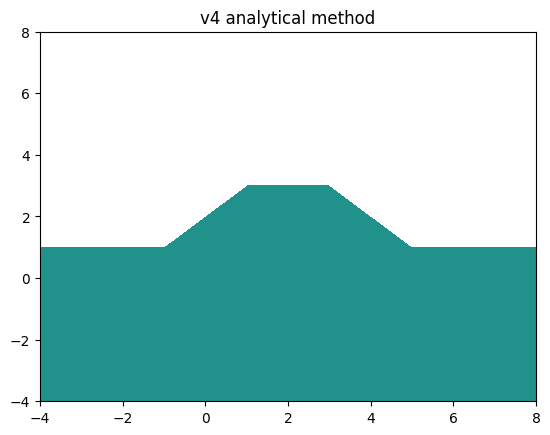

In [138]:
X1, X2 = np.meshgrid(np.linspace(-4, 8, 120), np.linspace(-4,8, 120))  # grid of points in 2D plane
P = np.stack((X1.flatten(),X2.flatten()), axis=1)                    # points formated for ANN input
Y = sess.run(y_a, feed_dict={x: P})                                    # ANN outputs for flatten grid  points
Z = np.reshape(Y,X1.shape)
print(Z.min(), Z.max())                                           # reshaping to shape of grid
plt.contourf(X1, X2, Z, levels=[0.5, 1.0])                           # curve for level=0.5 - a decision boundary, shaded class 1 area
plt.title('v4 analytical method')
plt.show()


4.3324825e-15 1.0


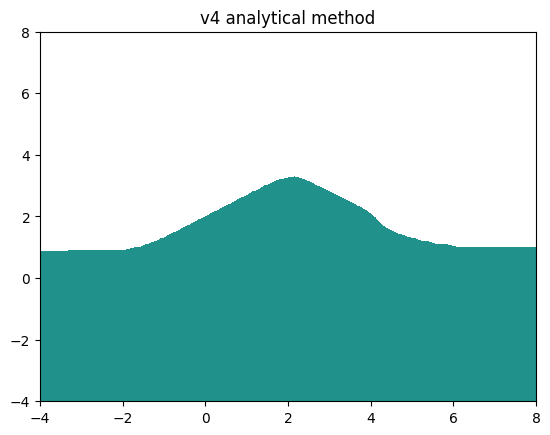

In [139]:
X1, X2 = np.meshgrid(np.linspace(-4, 8, 120), np.linspace(-4,8, 120))  # grid of points in 2D plane
P = np.stack((X1.flatten(),X2.flatten()), axis=1)                    # points formated for ANN input
Y = sess.run(y_train_prob, feed_dict={x: P})                                    # ANN outputs for flatten grid  points
Z = np.reshape(Y,X1.shape)
print(Z.min(), Z.max())                                           # reshaping to shape of grid
plt.contourf(X1, X2, Z, levels=[0.5, 1.0])                           # curve for level=0.5 - a decision boundary, shaded class 1 area
plt.title('v4 analytical method')
plt.show()


#### Drawing 3D mesh

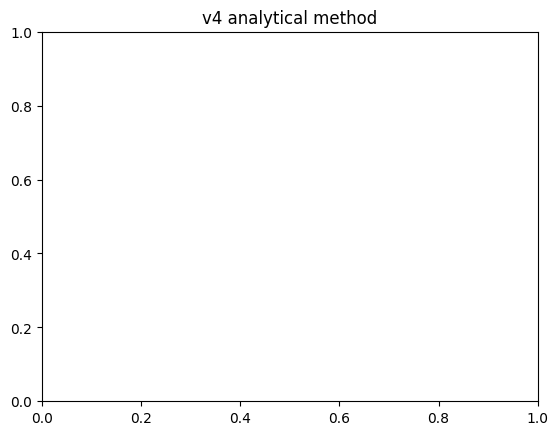

In [140]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.plot_surface(X1, X2, Z, rstride=1, cstride=1, cmap=cm.viridis)
plt.title('v4 analytical method')
plt.show()